# 04 - Option 4: Cross-dataset ICH prior transfer to PHE-SICH

Notebook này triển khai **Option 4**:

1. Train **ICH teacher** trên source datasets: **Seg-CQ500 + INSTANCE 2022**.
2. Dùng teacher sinh **soft hemorrhage prior** cho từng volume PHE-SICH.
3. Train **PHE student** trên PHE-SICH với input gồm:
   - brain/cerebral window CT `[-20, 100] HU`,
   - teacher hemorrhage-prior channel.
4. Đánh giá bằng cùng metric benchmark với Option 1:
   - PHE-SICH legacy: Dice, Jaccard, full HD, Precision, Recall.
   - PESE/INSTANCE-style: DSC, HD, RVD, NSD, volume MAE/RMSE/R2.

Điểm quan trọng: Option 4 **không pseudo-label IPH từ edema mask**. Prior đến từ teacher học trên source ICH ngoài miền.


## Thiết kế so sánh

| Option | Dữ liệu | Mục tiêu | Notebook |
|---|---|---|---|
| Option 1 | PHE-SICH only | Baseline PHE thuần | `01_option1_phe_sich_2d_unet_benchmark_metrics.ipynb` |
| Option 4 | Seg-CQ500 + INSTANCE -> PHE-SICH | Kiểm tra cross-dataset hemorrhage prior có giúp PHE không | notebook này |

Để so công bằng, notebook này dùng lại split PHE từ Option 1 nếu file split đã tồn tại.


In [1]:
INSTALL_BASIC_DEPS = False

if INSTALL_BASIC_DEPS:
    import sys
    import subprocess
    pkgs = ["numpy", "pandas", "matplotlib", "scipy", "nibabel", "tqdm"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *pkgs])


In [2]:
from pathlib import Path
from dataclasses import dataclass, asdict


@dataclass
class Option4Config:
    project_root: Path = Path.cwd()
    seed: int = 42

    # Run switches. Turn off individual stages if checkpoints/priors already exist.
    run_teacher_training: bool = True
    run_prior_generation: bool = True
    run_student_training: bool = True
    run_final_eval: bool = True

    # Debug mode for a quick wiring test.
    debug_small_run: bool = False
    debug_teacher_cases: int = 8
    debug_phe_train_cases: int = 8
    debug_phe_val_cases: int = 4
    debug_phe_test_cases: int = 4
    debug_epochs: int = 2

    # Teacher source ICH settings.
    teacher_image_size: int = 256
    teacher_epochs: int = 60
    teacher_batch_size: int = 8
    teacher_lr: float = 3e-4
    teacher_base_channels: int = 32
    teacher_positive_slice_weight: float = 4.0

    # Student target PHE settings, aligned with Option 1.
    student_image_size: int = 512
    student_epochs: int = 100
    student_batch_size: int = 4
    student_lr: float = 5e-5
    student_base_channels: int = 32
    student_positive_slice_weight: float = 4.0

    # Common optimization.
    weight_decay: float = 1e-4
    patience: int = 20
    min_delta: float = 1e-4
    amp: bool = True
    num_workers: int = 0

    # Windows.
    phe_window_low: float = -20.0
    phe_window_high: float = 100.0
    ich_window_low: float = -50.0
    ich_window_high: float = 150.0

    # Evaluation.
    threshold: float = 0.5
    tune_threshold_on_val: bool = True
    threshold_grid: tuple = (0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70)
    nsd_tolerance_mm: float = 1.0
    save_probability_npz: bool = False


CFG = Option4Config()
PROJECT_ROOT = CFG.project_root.resolve()

PHE_ROOT = PROJECT_ROOT / "PHE-SICH-CT-IDS" / "SubdatasetA_NIFIT" / "NIFIT"
PHE_IMAGE_DIR = PHE_ROOT / "set"
PHE_MASK_DIR = PHE_ROOT / "label"

SEG_CQ500_ROOT = PROJECT_ROOT / "Seg-CQ500" / "Seg-CQ500" / "data" / "volumes"
INSTANCE_ROOT = PROJECT_ROOT / "Instance2022" / "train_2"

OPTION1_SPLIT_PATH = PROJECT_ROOT / "outputs_option1_phe_sich_2d_unet" / "manifests" / "phe_sich_option1_patient_442_split.csv"

OUTPUT_ROOT = PROJECT_ROOT / "outputs_option4_ich_prior_transfer"
MANIFEST_DIR = OUTPUT_ROOT / "manifests"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR = OUTPUT_ROOT / "figures"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
PRIOR_DIR = OUTPUT_ROOT / "teacher_priors_phe"
PRED_DIR = OUTPUT_ROOT / "predictions"
LOG_DIR = OUTPUT_ROOT / "logs"

for p in [OUTPUT_ROOT, MANIFEST_DIR, TABLE_DIR, FIG_DIR, CHECKPOINT_DIR, PRIOR_DIR, PRED_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output root :", OUTPUT_ROOT)
print("PHE root    :", PHE_ROOT)
print("Seg-CQ500   :", SEG_CQ500_ROOT)
print("INSTANCE    :", INSTANCE_ROOT)


Project root: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao
Output root : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer
PHE root    : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-IDS\SubdatasetA_NIFIT\NIFIT
Seg-CQ500   : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Seg-CQ500\data\volumes
INSTANCE    : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Instance2022\train_2


In [3]:
import os
import json
import math
import random
import time
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    import nibabel as nib
    NIB_AVAILABLE = True
except Exception as exc:
    nib = None
    NIB_AVAILABLE = False
    print("nibabel unavailable:", exc)

try:
    from scipy import ndimage
    SCIPY_AVAILABLE = True
except Exception as exc:
    ndimage = None
    SCIPY_AVAILABLE = False
    print("scipy unavailable:", exc)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
    TORCH_AVAILABLE = True
except Exception as exc:
    torch = nn = F = Dataset = DataLoader = WeightedRandomSampler = None
    TORCH_AVAILABLE = False
    print("torch unavailable; training/eval checkpoint cells will skip:", exc)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


set_seed(CFG.seed)
DEVICE = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
print({"nibabel": NIB_AVAILABLE, "scipy": SCIPY_AVAILABLE, "torch": TORCH_AVAILABLE, "device": DEVICE})


{'nibabel': True, 'scipy': True, 'torch': True, 'device': 'cuda'}


## 1. Shared NIfTI, preprocessing, split helpers


In [4]:
def is_nifti(path: Path) -> bool:
    return path.name.endswith(".nii") or path.name.endswith(".nii.gz")


def strip_nii_suffix(path_or_name) -> str:
    name = Path(path_or_name).name
    if name.endswith(".nii.gz"):
        return name[:-7]
    if name.endswith(".nii"):
        return name[:-4]
    return Path(name).stem


def load_nifti(path: Path, canonical: bool = True):
    if not NIB_AVAILABLE:
        raise ImportError("Install nibabel first.")
    img = nib.load(str(path))
    if canonical:
        img = nib.as_closest_canonical(img)
    data = np.asanyarray(img.dataobj)
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return data, spacing, img.affine


def header_info(path: Path) -> Dict:
    img = nib.load(str(path))
    shape = tuple(int(v) for v in img.shape[:3])
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return {"shape": shape, "spacing_x": spacing[0], "spacing_y": spacing[1], "spacing_z": spacing[2], "n_slices": shape[2]}


def mask_volume_stats(mask_path: Path, spacing: Tuple[float, float, float]) -> Dict:
    mask = np.asanyarray(nib.load(str(mask_path)).dataobj) > 0
    per_slice = mask.reshape((-1, mask.shape[2])).sum(axis=0)
    voxel_ml = float(np.prod(spacing) / 1000.0)
    return {"mask_voxels": int(mask.sum()), "mask_volume_ml": float(mask.sum() * voxel_ml), "positive_slices": int((per_slice > 0).sum())}


def window_ct(image: np.ndarray, low: float, high: float) -> np.ndarray:
    image = image.astype(np.float32, copy=False)
    image = np.clip(image, low, high)
    return ((image - low) / max(high - low, 1e-6)).astype(np.float32)


def resize_2d(array: np.ndarray, out_size: int, order: int = 1) -> np.ndarray:
    if array.shape[-2:] == (out_size, out_size):
        return array
    if not SCIPY_AVAILABLE:
        raise ImportError("Install scipy for resizing.")
    zoom_y = out_size / array.shape[-2]
    zoom_x = out_size / array.shape[-1]
    return ndimage.zoom(array, (zoom_y, zoom_x), order=order)


def preprocess_slice(volume: np.ndarray, z: int, image_size: int, low: float, high: float) -> np.ndarray:
    x = window_ct(np.asarray(volume[:, :, z]), low, high)
    return resize_2d(x, image_size, order=1).astype(np.float32)


def preprocess_mask_slice(mask_volume: np.ndarray, z: int, image_size: int) -> np.ndarray:
    y = (np.asarray(mask_volume[:, :, z]) > 0).astype(np.float32)
    return (resize_2d(y, image_size, order=0) > 0.5).astype(np.float32)


def largest_mask_slice(mask_volume: np.ndarray) -> int:
    per_slice = (mask_volume > 0).reshape((-1, mask_volume.shape[2])).sum(axis=0)
    return int(np.argmax(per_slice))


def torch_load_checkpoint(path: Path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


## 2. Build source ICH manifests: Seg-CQ500 + INSTANCE


In [5]:
def build_seg_cq500_manifest() -> pd.DataFrame:
    rows = []
    if not SEG_CQ500_ROOT.exists():
        return pd.DataFrame()
    for case_dir in sorted(p for p in SEG_CQ500_ROOT.iterdir() if p.is_dir()):
        img_path = case_dir / "CT.nii"
        mask_path = case_dir / "ICH_mask.nii.gz"
        if not img_path.exists() or not mask_path.exists():
            continue
        info = header_info(img_path)
        spacing = (info["spacing_x"], info["spacing_y"], info["spacing_z"])
        stats = mask_volume_stats(mask_path, spacing)
        rows.append({
            "dataset": "Seg-CQ500",
            "role": "source_ich",
            "patient_id": case_dir.name,
            "scan_id": case_dir.name,
            "img_path": str(img_path),
            "mask_path": str(mask_path),
            "license_note": "CC BY 4.0",
            **info,
            **stats,
        })
    return pd.DataFrame(rows)


def build_instance_manifest() -> pd.DataFrame:
    rows = []
    data_dir = INSTANCE_ROOT / "data"
    label_dir = INSTANCE_ROOT / "label"
    if not data_dir.exists() or not label_dir.exists():
        return pd.DataFrame()
    images = {strip_nii_suffix(p): p for p in data_dir.iterdir() if p.is_file() and is_nifti(p)}
    masks = {strip_nii_suffix(p): p for p in label_dir.iterdir() if p.is_file() and is_nifti(p)}
    for scan_id, img_path in sorted(images.items()):
        mask_path = masks.get(scan_id)
        if not mask_path:
            continue
        info = header_info(img_path)
        spacing = (info["spacing_x"], info["spacing_y"], info["spacing_z"])
        stats = mask_volume_stats(mask_path, spacing)
        rows.append({
            "dataset": "INSTANCE2022",
            "role": "source_ich",
            "patient_id": f"instance_{scan_id}",
            "scan_id": scan_id,
            "img_path": str(img_path),
            "mask_path": str(mask_path),
            "license_note": "Challenge terms; verify before redistribution",
            **info,
            **stats,
        })
    return pd.DataFrame(rows)


source_df = pd.concat([build_seg_cq500_manifest(), build_instance_manifest()], ignore_index=True)
if CFG.debug_small_run:
    source_df = source_df.groupby("dataset", group_keys=False).head(max(1, CFG.debug_teacher_cases // 2)).reset_index(drop=True)
source_path = MANIFEST_DIR / "option4_source_ich_manifest.csv"
source_df.to_csv(source_path, index=False, encoding="utf-8")
display(source_df.groupby("dataset").agg(cases=("scan_id", "count"), slices=("n_slices", "sum"), positive_slices=("positive_slices", "sum"), median_spacing_z=("spacing_z", "median")).reset_index())
print("Saved:", source_path)


,dataset,cases,slices,positive_slices,median_spacing_z
0,INSTANCE2022,100,2981,893,5.000000
1,Seg-CQ500,51,11175,3500,0.630317


Saved: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\manifests\option4_source_ich_manifest.csv


## 3. Build/load PHE-SICH split


In [6]:
def build_phe_manifest() -> pd.DataFrame:
    images = {strip_nii_suffix(p): p for p in PHE_IMAGE_DIR.iterdir() if p.is_file() and is_nifti(p)}
    masks = {strip_nii_suffix(p): p for p in PHE_MASK_DIR.iterdir() if p.is_file() and is_nifti(p)}
    rows = []
    for scan_id, img_path in sorted(images.items()):
        mask_path = masks.get(scan_id)
        if mask_path is None:
            continue
        info = header_info(img_path)
        spacing = (info["spacing_x"], info["spacing_y"], info["spacing_z"])
        stats = mask_volume_stats(mask_path, spacing)
        rows.append({
            "dataset": "PHE-SICH-CT-IDS",
            "role": "target_phe",
            "patient_id": f"phe_{scan_id}",
            "scan_id": scan_id,
            "img_path": str(img_path),
            "mask_path": str(mask_path),
            "license_note": "CC BY 4.0",
            **info,
            **stats,
        })
    return pd.DataFrame(rows)


def make_patient_442_split(df: pd.DataFrame, seed: int = CFG.seed) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)
    rng = np.random.default_rng(seed)
    strata = pd.qcut(df["mask_volume_ml"].rank(method="first"), q=4, labels=False)
    split = np.array([""] * len(df), dtype=object)
    for _, part in df.groupby(strata):
        idx = part.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(round(n * 0.4))
        n_val = int(round(n * 0.4))
        split[idx[:n_train]] = "train"
        split[idx[n_train:n_train + n_val]] = "val"
        split[idx[n_train + n_val:]] = "test"
    df["split"] = split
    return df


if OPTION1_SPLIT_PATH.exists():
    phe_df = pd.read_csv(OPTION1_SPLIT_PATH)
    print("Loaded Option 1 PHE split:", OPTION1_SPLIT_PATH)
else:
    phe_df = make_patient_442_split(build_phe_manifest())
    print("Built new PHE split with seed:", CFG.seed)

if CFG.debug_small_run:
    phe_df = pd.concat([
        phe_df[phe_df["split"] == "train"].head(CFG.debug_phe_train_cases),
        phe_df[phe_df["split"] == "val"].head(CFG.debug_phe_val_cases),
        phe_df[phe_df["split"] == "test"].head(CFG.debug_phe_test_cases),
    ], ignore_index=True)

phe_path = MANIFEST_DIR / "option4_phe_split.csv"
phe_df.to_csv(phe_path, index=False, encoding="utf-8")
train_rows = phe_df[phe_df["split"] == "train"].reset_index(drop=True)
val_rows = phe_df[phe_df["split"] == "val"].reset_index(drop=True)
test_rows = phe_df[phe_df["split"] == "test"].reset_index(drop=True)
display(phe_df.groupby("split").agg(cases=("scan_id", "count"), slices=("n_slices", "sum"), positive_slices=("positive_slices", "sum"), median_phe_ml=("mask_volume_ml", "median")).reset_index())
print("Saved:", phe_path)


Loaded Option 1 PHE split: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option1_phe_sich_2d_unet\manifests\phe_sich_option1_patient_442_split.csv


,split,cases,slices,positive_slices,median_phe_ml
0,test,24,799,130,2.548099
1,train,48,1368,284,2.585669
2,val,48,1434,269,2.512041


Saved: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\manifests\option4_phe_split.csv


## 4. Metrics, shared with Option 1


In [7]:
def diagonal_distance(shape: Sequence[int], sampling: Optional[Sequence[float]] = None) -> float:
    if sampling is None:
        sampling = [1.0] * len(shape)
    return float(math.sqrt(sum(((int(s) - 1) * float(sp)) ** 2 for s, sp in zip(shape, sampling))))


def confusion_counts(pred: np.ndarray, target: np.ndarray):
    pred = pred.astype(bool)
    target = target.astype(bool)
    tp = int(np.logical_and(pred, target).sum())
    fp = int(np.logical_and(pred, ~target).sum())
    fn = int(np.logical_and(~pred, target).sum())
    tn = int(np.logical_and(~pred, ~target).sum())
    return tp, fp, fn, tn


def overlap_metrics(pred: np.ndarray, target: np.ndarray) -> Dict:
    tp, fp, fn, tn = confusion_counts(pred, target)
    if tp + fp + fn == 0:
        return {"dice": np.nan, "jaccard": np.nan, "precision": np.nan, "recall": np.nan, "tp": tp, "fp": fp, "fn": fn, "tn": tn}
    return {
        "dice": float((2 * tp) / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else np.nan,
        "jaccard": float(tp / (tp + fp + fn)) if (tp + fp + fn) else np.nan,
        "precision": float(tp / (tp + fp)) if (tp + fp) else 0.0,
        "recall": float(tp / (tp + fn)) if (tp + fn) else 0.0,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }


def surface_mask(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    structure = np.ones((3, 3), dtype=bool) if mask.ndim == 2 else ndimage.generate_binary_structure(3, 1)
    eroded = ndimage.binary_erosion(mask, structure=structure, border_value=0)
    return np.logical_xor(mask, eroded)


def hausdorff_distance(pred: np.ndarray, target: np.ndarray, sampling=None, empty_penalty: bool = True) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return np.nan
    if pred.sum() == 0 or target.sum() == 0:
        return diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
    sp = surface_mask(pred)
    st = surface_mask(target)
    dt_to_target = ndimage.distance_transform_edt(~st, sampling=sampling)
    dt_to_pred = ndimage.distance_transform_edt(~sp, sampling=sampling)
    d1 = dt_to_target[sp]
    d2 = dt_to_pred[st]
    if len(d1) == 0 or len(d2) == 0:
        return diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
    return float(max(d1.max(), d2.max()))


def normalized_surface_dice(pred: np.ndarray, target: np.ndarray, spacing: Tuple[float, float, float], tolerance_mm: float = CFG.nsd_tolerance_mm) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return np.nan
    if pred.sum() == 0 or target.sum() == 0:
        return 0.0
    sp = surface_mask(pred)
    st = surface_mask(target)
    dt_to_target = ndimage.distance_transform_edt(~st, sampling=spacing)
    dt_to_pred = ndimage.distance_transform_edt(~sp, sampling=spacing)
    pred_close = int((dt_to_target[sp] <= tolerance_mm).sum())
    target_close = int((dt_to_pred[st] <= tolerance_mm).sum())
    denom = int(sp.sum() + st.sum())
    return float((pred_close + target_close) / denom) if denom else np.nan


def volume_ml(mask: np.ndarray, spacing: Tuple[float, float, float]) -> float:
    return float((mask.astype(bool).sum() * np.prod(spacing)) / 1000.0)


def rvd_abs(pred: np.ndarray, target: np.ndarray) -> float:
    pred_vox = float(pred.astype(bool).sum())
    target_vox = float(target.astype(bool).sum())
    if target_vox == 0:
        return np.nan if pred_vox == 0 else np.inf
    return float(abs(pred_vox - target_vox) / target_vox)


def r2_score_np(y_true: Sequence[float], y_pred: Sequence[float]) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    ss_res = float(((y_true - y_pred) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def summarize_metrics(df: pd.DataFrame, group_name: str, cols: Optional[List[str]] = None) -> pd.DataFrame:
    cols = cols or ["dice", "jaccard", "hd_px", "hd_mm", "precision", "recall", "dsc", "rvd", "nsd", "volume_abs_error_ml"]
    rows = []
    for col in cols:
        if col not in df.columns:
            continue
        values = pd.to_numeric(df[col], errors="coerce")
        finite = values.replace([np.inf, -np.inf], np.nan)
        rows.append({"group": group_name, "metric": col, "mean": finite.mean(), "std": finite.std(), "median": finite.median(), "n": int(finite.notna().sum()), "n_inf": int(np.isinf(values).sum())})
    return pd.DataFrame(rows)


In [8]:
def evaluate_slice_predictions_for_case(row: pd.Series, pred_volume: np.ndarray, positive_gt_only: bool = False) -> pd.DataFrame:
    target, spacing, _ = load_nifti(Path(row["mask_path"]))
    target = target > 0
    pred = pred_volume.astype(bool)
    rows = []
    for z in range(target.shape[2]):
        if positive_gt_only and target[:, :, z].sum() == 0:
            continue
        m = overlap_metrics(pred[:, :, z], target[:, :, z])
        m["hd_px"] = hausdorff_distance(pred[:, :, z], target[:, :, z], sampling=None, empty_penalty=True)
        m["hd_mm"] = hausdorff_distance(pred[:, :, z], target[:, :, z], sampling=spacing[:2], empty_penalty=True)
        rows.append({"scan_id": row["scan_id"], "slice_idx": z, **m})
    return pd.DataFrame(rows)


def evaluate_volume_prediction_for_case(row: pd.Series, pred_volume: np.ndarray) -> Dict:
    target, spacing, _ = load_nifti(Path(row["mask_path"]))
    target = target > 0
    pred = pred_volume.astype(bool)
    overlap = overlap_metrics(pred, target)
    pred_ml = volume_ml(pred, spacing)
    target_ml = volume_ml(target, spacing)
    return {
        "scan_id": row["scan_id"],
        "dsc": overlap["dice"],
        "jaccard_3d": overlap["jaccard"],
        "precision_3d": overlap["precision"],
        "recall_3d": overlap["recall"],
        "hd_mm": hausdorff_distance(pred, target, sampling=spacing, empty_penalty=True),
        "rvd": rvd_abs(pred, target),
        "nsd": normalized_surface_dice(pred, target, spacing),
        "pred_volume_ml": pred_ml,
        "target_volume_ml": target_ml,
        "volume_abs_error_ml": abs(pred_ml - target_ml),
        "volume_sq_error_ml2": (pred_ml - target_ml) ** 2,
    }


## 5. Models and datasets


In [9]:
if TORCH_AVAILABLE:
    class SliceSegDataset(Dataset):
        def __init__(self, df: pd.DataFrame, task: str, image_size: int, window_low: float, window_high: float, augment: bool = False, max_cases: Optional[int] = None):
            self.df = df.copy().reset_index(drop=True)
            if max_cases is not None:
                self.df = self.df.head(max_cases).copy().reset_index(drop=True)
            self.task = task
            self.image_size = int(image_size)
            self.window_low = float(window_low)
            self.window_high = float(window_high)
            self.augment = bool(augment)
            self.cache = {}
            self.slice_df = self._build_slice_index()

        def _build_slice_index(self):
            rows = []
            for row_idx, row in self.df.iterrows():
                mask, _, _ = load_nifti(Path(row["mask_path"]))
                mask = mask > 0
                n = mask.shape[2]
                per_slice = mask.reshape((-1, n)).sum(axis=0)
                for z in range(n):
                    rows.append({"row_idx": row_idx, "scan_id": row["scan_id"], "slice_idx": int(z), "positive": bool(per_slice[z] > 0)})
            return pd.DataFrame(rows)

        def _load_case(self, row_idx):
            if row_idx not in self.cache:
                row = self.df.iloc[row_idx]
                image, spacing, _ = load_nifti(Path(row["img_path"]))
                mask, _, _ = load_nifti(Path(row["mask_path"]))
                self.cache[row_idx] = (image.astype(np.float32), (mask > 0).astype(np.uint8), spacing)
            return self.cache[row_idx]

        def _augment(self, x, y):
            if random.random() < 0.5:
                x = np.flip(x, axis=1).copy()
                y = np.flip(y, axis=1).copy()
            if random.random() < 0.20:
                angle = random.uniform(-10.0, 10.0)
                x = ndimage.rotate(x, angle, reshape=False, order=1, mode="nearest")
                y = ndimage.rotate(y, angle, reshape=False, order=0, mode="nearest")
            if random.random() < 0.20:
                gamma = random.uniform(0.85, 1.15)
                x = np.clip(x, 0, 1) ** gamma
            return x.astype(np.float32), (y > 0.5).astype(np.float32)

        def __len__(self):
            return len(self.slice_df)

        def __getitem__(self, idx):
            item = self.slice_df.iloc[idx]
            image, mask, spacing = self._load_case(int(item["row_idx"]))
            z = int(item["slice_idx"])
            x = preprocess_slice(image, z, self.image_size, self.window_low, self.window_high)
            y = preprocess_mask_slice(mask, z, self.image_size)
            if self.augment:
                x, y = self._augment(x, y)
            return {"image": torch.from_numpy(x[None]).float(), "mask": torch.from_numpy(y[None]).float(), "scan_id": str(item["scan_id"]), "slice_idx": z, "positive": bool(item["positive"]), "spacing": torch.tensor(spacing, dtype=torch.float32)}


    class PhePriorSliceDataset(Dataset):
        def __init__(self, df: pd.DataFrame, image_size: int, augment: bool = False):
            self.df = df.copy().reset_index(drop=True)
            self.image_size = int(image_size)
            self.augment = bool(augment)
            self.cache = {}
            self.prior_cache = {}
            self.slice_df = self._build_slice_index()

        def _build_slice_index(self):
            rows = []
            for row_idx, row in self.df.iterrows():
                mask, _, _ = load_nifti(Path(row["mask_path"]))
                mask = mask > 0
                n = mask.shape[2]
                per_slice = mask.reshape((-1, n)).sum(axis=0)
                for z in range(n):
                    rows.append({"row_idx": row_idx, "scan_id": row["scan_id"], "slice_idx": int(z), "positive": bool(per_slice[z] > 0)})
            return pd.DataFrame(rows)

        def _load_case(self, row_idx):
            if row_idx not in self.cache:
                row = self.df.iloc[row_idx]
                image, spacing, _ = load_nifti(Path(row["img_path"]))
                mask, _, _ = load_nifti(Path(row["mask_path"]))
                self.cache[row_idx] = (image.astype(np.float32), (mask > 0).astype(np.uint8), spacing)
            return self.cache[row_idx]

        def _load_prior(self, scan_id: str):
            if scan_id not in self.prior_cache:
                p = PRIOR_DIR / f"{scan_id}_ich_prior.npz"
                if p.exists():
                    self.prior_cache[scan_id] = np.load(p)["prior"].astype(np.float32)
                else:
                    self.prior_cache[scan_id] = None
            return self.prior_cache[scan_id]

        def _augment(self, x, prior, y):
            if random.random() < 0.5:
                x = np.flip(x, axis=1).copy()
                prior = np.flip(prior, axis=1).copy()
                y = np.flip(y, axis=1).copy()
            if random.random() < 0.20:
                angle = random.uniform(-10.0, 10.0)
                x = ndimage.rotate(x, angle, reshape=False, order=1, mode="nearest")
                prior = ndimage.rotate(prior, angle, reshape=False, order=1, mode="nearest")
                y = ndimage.rotate(y, angle, reshape=False, order=0, mode="nearest")
            return x.astype(np.float32), prior.astype(np.float32), (y > 0.5).astype(np.float32)

        def __len__(self):
            return len(self.slice_df)

        def __getitem__(self, idx):
            item = self.slice_df.iloc[idx]
            row_idx = int(item["row_idx"])
            row = self.df.iloc[row_idx]
            image, mask, spacing = self._load_case(row_idx)
            z = int(item["slice_idx"])
            x = preprocess_slice(image, z, self.image_size, CFG.phe_window_low, CFG.phe_window_high)
            y = preprocess_mask_slice(mask, z, self.image_size)
            prior_vol = self._load_prior(str(row["scan_id"]))
            if prior_vol is None:
                prior = np.zeros_like(x, dtype=np.float32)
            else:
                prior = resize_2d(prior_vol[:, :, z], self.image_size, order=1).astype(np.float32)
            if self.augment:
                x, prior, y = self._augment(x, prior, y)
            stacked = np.stack([x, prior], axis=0)
            return {"image": torch.from_numpy(stacked).float(), "mask": torch.from_numpy(y[None]).float(), "scan_id": str(row["scan_id"]), "slice_idx": z, "positive": bool(item["positive"]), "spacing": torch.tensor(spacing, dtype=torch.float32)}
else:
    print("Torch unavailable. Dataset classes skipped.")


In [10]:
if TORCH_AVAILABLE:
    class ConvBlock(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        def forward(self, x):
            return self.net(x)


    class UNet2D(nn.Module):
        def __init__(self, in_channels=1, base=32):
            super().__init__()
            self.enc1 = ConvBlock(in_channels, base)
            self.enc2 = ConvBlock(base, base * 2)
            self.enc3 = ConvBlock(base * 2, base * 4)
            self.enc4 = ConvBlock(base * 4, base * 8)
            self.pool = nn.MaxPool2d(2)
            self.bottleneck = ConvBlock(base * 8, base * 16)
            self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
            self.dec4 = ConvBlock(base * 16, base * 8)
            self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
            self.dec3 = ConvBlock(base * 8, base * 4)
            self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
            self.dec2 = ConvBlock(base * 4, base * 2)
            self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
            self.dec1 = ConvBlock(base * 2, base)
            self.out = nn.Conv2d(base, 1, 1)

        def forward(self, x):
            e1 = self.enc1(x)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))
            e4 = self.enc4(self.pool(e3))
            b = self.bottleneck(self.pool(e4))
            d4 = self.up4(b)
            d4 = self.dec4(torch.cat([d4, e4], dim=1))
            d3 = self.up3(d4)
            d3 = self.dec3(torch.cat([d3, e3], dim=1))
            d2 = self.up2(d3)
            d2 = self.dec2(torch.cat([d2, e2], dim=1))
            d1 = self.up1(d2)
            d1 = self.dec1(torch.cat([d1, e1], dim=1))
            return self.out(d1)


    def dice_loss_from_logits(logits, targets, eps=1e-6):
        probs = torch.sigmoid(logits)
        dims = tuple(range(1, probs.ndim))
        inter = (probs * targets).sum(dims)
        union = probs.sum(dims) + targets.sum(dims)
        return 1.0 - ((2 * inter + eps) / (union + eps)).mean()


    def make_seg_loss(pos_weight_value: float):
        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
        def loss_fn(logits, targets):
            bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
            return bce + dice_loss_from_logits(logits, targets)
        return loss_fn
else:
    print("Torch unavailable. Model classes skipped.")


## 6. Teacher training on source ICH


In [11]:
if TORCH_AVAILABLE:
    def make_source_split(df: pd.DataFrame, val_fraction: float = 0.2, seed: int = CFG.seed):
        rng = np.random.default_rng(seed)
        train_idx, val_idx = [], []
        for dataset, part in df.groupby("dataset"):
            idx = part.index.to_numpy().copy()
            rng.shuffle(idx)
            n_val = max(1, int(round(len(idx) * val_fraction)))
            val_idx.extend(idx[:n_val])
            train_idx.extend(idx[n_val:])
        return df.loc[train_idx].reset_index(drop=True), df.loc[val_idx].reset_index(drop=True)


    def positive_pixel_weight(df: pd.DataFrame, clip: float = 50.0):
        pos = 0
        total = 0
        for _, row in df.iterrows():
            mask, _, _ = load_nifti(Path(row["mask_path"]))
            pos += int((mask > 0).sum())
            total += int(np.prod(mask.shape))
        neg = max(total - pos, 1)
        return float(min(neg / max(pos, 1), clip))


    def make_loader(ds, batch_size, positive_weight, shuffle=False):
        weights = np.where(ds.slice_df["positive"].to_numpy(bool), positive_weight, 1.0).astype(np.float64)
        sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True) if shuffle else None
        return DataLoader(ds, batch_size=batch_size, sampler=sampler, shuffle=False if sampler else shuffle, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))


    source_train_df, source_val_df = make_source_split(source_df)
    teacher_train_ds = SliceSegDataset(source_train_df, task="ich", image_size=CFG.teacher_image_size, window_low=CFG.ich_window_low, window_high=CFG.ich_window_high, augment=True)
    teacher_val_ds = SliceSegDataset(source_val_df, task="ich", image_size=CFG.teacher_image_size, window_low=CFG.ich_window_low, window_high=CFG.ich_window_high, augment=False)
    teacher_train_loader = make_loader(teacher_train_ds, CFG.teacher_batch_size, CFG.teacher_positive_slice_weight, shuffle=True)
    teacher_val_loader = DataLoader(teacher_val_ds, batch_size=CFG.teacher_batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))
    teacher_pos_weight = positive_pixel_weight(source_train_df)
    display(pd.DataFrame([
        {"split": "source_train", "cases": len(source_train_df), "slices": len(teacher_train_ds), "positive_slices": int(teacher_train_ds.slice_df["positive"].sum())},
        {"split": "source_val", "cases": len(source_val_df), "slices": len(teacher_val_ds), "positive_slices": int(teacher_val_ds.slice_df["positive"].sum())},
    ]))
    print("teacher pos_weight:", teacher_pos_weight)
else:
    print("Torch unavailable. Teacher data skipped.")


,split,cases,slices,positive_slices
0,source_train,121,10851,3433
1,source_val,30,3305,960


teacher pos_weight: 50.0


In [12]:
if TORCH_AVAILABLE:
    def train_seg_epoch(model, loader, optimizer, loss_fn, desc):
        model.train()
        scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))
        losses = []
        for batch in tqdm(loader, desc=desc, leave=False):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["mask"].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
                logits = model(x)
                loss = loss_fn(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        return float(np.mean(losses)) if losses else np.nan


    @torch.no_grad()
    def validate_seg_slices(model, loader, loss_fn):
        model.eval()
        losses, dices, precs, recs = [], [], [], []
        for batch in tqdm(loader, desc="val", leave=False):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["mask"].to(DEVICE, non_blocking=True)
            logits = model(x)
            losses.append(float(loss_fn(logits, y).detach().cpu()))
            prob = torch.sigmoid(logits).cpu().numpy()[:, 0]
            target = y.cpu().numpy()[:, 0] > 0
            pred = prob >= CFG.threshold
            for i in range(pred.shape[0]):
                if target[i].sum() == 0:
                    continue
                m = overlap_metrics(pred[i], target[i])
                dices.append(m["dice"])
                precs.append(m["precision"])
                recs.append(m["recall"])
        return {"loss": float(np.mean(losses)) if losses else np.nan, "dice_pos": float(np.nanmean(dices)) if dices else np.nan, "precision_pos": float(np.nanmean(precs)) if precs else np.nan, "recall_pos": float(np.nanmean(recs)) if recs else np.nan}


    teacher_ckpt = CHECKPOINT_DIR / "option4_ich_teacher_best.pt"
    if CFG.run_teacher_training:
        teacher = UNet2D(in_channels=1, base=CFG.teacher_base_channels).to(DEVICE)
        teacher_loss = make_seg_loss(teacher_pos_weight)
        teacher_opt = torch.optim.AdamW(teacher.parameters(), lr=CFG.teacher_lr, weight_decay=CFG.weight_decay)
        epochs = CFG.debug_epochs if CFG.debug_small_run else CFG.teacher_epochs
        best = -np.inf
        bad = 0
        teacher_history = []
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            tr_loss = train_seg_epoch(teacher, teacher_train_loader, teacher_opt, teacher_loss, f"teacher {epoch}")
            val_m = validate_seg_slices(teacher, teacher_val_loader, teacher_loss)
            row = {"epoch": epoch, "sec": time.time() - t0, "train_loss": tr_loss, **{f"val_{k}": v for k, v in val_m.items()}}
            teacher_history.append(row)
            print(row)
            pd.DataFrame(teacher_history).to_csv(LOG_DIR / "option4_teacher_training_log.csv", index=False)
            score = val_m["dice_pos"]
            if np.isfinite(score) and score > best + CFG.min_delta:
                best = score
                bad = 0
                torch.save({"model": teacher.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "best_metric": best}, teacher_ckpt)
                print("Saved teacher:", teacher_ckpt)
            else:
                bad += 1
            if bad >= CFG.patience:
                print("Teacher early stopping.")
                break
    else:
        print("Teacher training disabled.")
else:
    print("Torch unavailable. Teacher training skipped.")


C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


teacher 1:   0%|          | 0/1357 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):


val:   0%|          | 0/414 [00:00<?, ?it/s]

{'epoch': 1, 'sec': 169.70497298240662, 'train_loss': 1.299615293807112, 'val_loss': 1.0800731684562666, 'val_dice_pos': 0.36106330636318607, 'val_precision_pos': 0.3072349865100274, 'val_recall_pos': 0.63273899219524}
Saved teacher: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\checkpoints\option4_ich_teacher_best.pt


...

C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


teacher 24:   0%|          | 0/1357 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):


val:   0%|          | 0/414 [00:00<?, ?it/s]

{'epoch': 24, 'sec': 125.48077654838562, 'train_loss': 0.5336400072365538, 'val_loss': 1.1432908541086504, 'val_dice_pos': 0.5274386855364646, 'val_precision_pos': 0.6389949536057522, 'val_recall_pos': 0.5211605323565387}
Teacher early stopping.


## 7. Generate soft ICH priors on PHE-SICH


In [13]:
if TORCH_AVAILABLE:
    @torch.no_grad()
    def predict_teacher_prior_volume(model, row: pd.Series, image_size: int = CFG.teacher_image_size):
        model.eval()
        image, spacing, _ = load_nifti(Path(row["img_path"]))
        priors = []
        for z in range(image.shape[2]):
            x = preprocess_slice(image, z, image_size, CFG.ich_window_low, CFG.ich_window_high)[None, None]
            xb = torch.from_numpy(x).float().to(DEVICE)
            prob = torch.sigmoid(model(xb))[0, 0].detach().cpu().numpy()
            prob = resize_2d(prob, image.shape[0], order=1)
            if prob.shape != image.shape[:2]:
                prob = ndimage.zoom(prob, (image.shape[0] / prob.shape[0], image.shape[1] / prob.shape[1]), order=1)
            priors.append(prob.astype(np.float16))
        return np.stack(priors, axis=2)


    def load_teacher_model():
        if not teacher_ckpt.exists():
            return None
        m = UNet2D(in_channels=1, base=CFG.teacher_base_channels).to(DEVICE)
        state = torch_load_checkpoint(teacher_ckpt)
        m.load_state_dict(state["model"])
        m.eval()
        return m


    if CFG.run_prior_generation:
        teacher_for_prior = load_teacher_model()
        if teacher_for_prior is None:
            print("No teacher checkpoint found; train teacher first:", teacher_ckpt)
        else:
            for _, row in tqdm(phe_df.iterrows(), total=len(phe_df), desc="PHE priors"):
                out_path = PRIOR_DIR / f"{row['scan_id']}_ich_prior.npz"
                if out_path.exists():
                    continue
                prior = predict_teacher_prior_volume(teacher_for_prior, row)
                np.savez_compressed(out_path, prior=prior)
            print("Prior directory:", PRIOR_DIR)
            print("Priors:", len(list(PRIOR_DIR.glob("*_ich_prior.npz"))))
    else:
        print("Prior generation disabled.")
else:
    print("Torch unavailable. Prior generation skipped.")


PHE priors:   0%|          | 0/120 [00:00<?, ?it/s]

Prior directory: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\teacher_priors_phe
Priors: 120


## 8. Student training on PHE-SICH with prior channel


In [14]:
if TORCH_AVAILABLE:
    student_train_ds = PhePriorSliceDataset(train_rows, CFG.student_image_size, augment=True)
    student_val_ds = PhePriorSliceDataset(val_rows, CFG.student_image_size, augment=False)
    student_train_loader = make_loader(student_train_ds, CFG.student_batch_size, CFG.student_positive_slice_weight, shuffle=True)
    student_val_loader = DataLoader(student_val_ds, batch_size=CFG.student_batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))
    student_pos_weight = positive_pixel_weight(train_rows)
    display(pd.DataFrame([
        {"split": "phe_train", "cases": len(train_rows), "slices": len(student_train_ds), "positive_slices": int(student_train_ds.slice_df["positive"].sum())},
        {"split": "phe_val", "cases": len(val_rows), "slices": len(student_val_ds), "positive_slices": int(student_val_ds.slice_df["positive"].sum())},
    ]))
    print("student pos_weight:", student_pos_weight)
else:
    print("Torch unavailable. Student data skipped.")


,split,cases,slices,positive_slices
0,phe_train,48,1368,284
1,phe_val,48,1434,269


student pos_weight: 50.0


In [15]:
if TORCH_AVAILABLE:
    student_ckpt = CHECKPOINT_DIR / "option4_phe_student_prior_best.pt"
    if CFG.run_student_training:
        student = UNet2D(in_channels=2, base=CFG.student_base_channels).to(DEVICE)
        student_loss = make_seg_loss(student_pos_weight)
        student_opt = torch.optim.AdamW(student.parameters(), lr=CFG.student_lr, weight_decay=CFG.weight_decay)
        epochs = CFG.debug_epochs if CFG.debug_small_run else CFG.student_epochs
        best = -np.inf
        bad = 0
        student_history = []
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            tr_loss = train_seg_epoch(student, student_train_loader, student_opt, student_loss, f"student {epoch}")
            val_m = validate_seg_slices(student, student_val_loader, student_loss)
            row = {"epoch": epoch, "sec": time.time() - t0, "train_loss": tr_loss, **{f"val_{k}": v for k, v in val_m.items()}}
            student_history.append(row)
            print(row)
            pd.DataFrame(student_history).to_csv(LOG_DIR / "option4_student_training_log.csv", index=False)
            score = val_m["dice_pos"]
            if np.isfinite(score) and score > best + CFG.min_delta:
                best = score
                bad = 0
                torch.save({"model": student.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "best_metric": best}, student_ckpt)
                print("Saved student:", student_ckpt)
            else:
                bad += 1
            if bad >= CFG.patience:
                print("Student early stopping.")
                break
    else:
        print("Student training disabled.")
else:
    print("Torch unavailable. Student training skipped.")


C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


student 1:   0%|          | 0/342 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(e

val:   0%|          | 0/359 [00:00<?, ?it/s]

{'epoch': 1, 'sec': 98.65099382400513, 'train_loss': 1.5200657342609607, 'val_loss': 1.4201664316953058, 'val_dice_pos': 0.18323366446519693, 'val_precision_pos': 0.1119055008560932, 'val_recall_pos': 0.9173953054140974}
Saved student: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\checkpoints\option4_phe_student_prior_best.pt


...

C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


student 45:   0%|          | 0/342 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_22132\4052286808.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):


val:   0%|          | 0/359 [00:00<?, ?it/s]

{'epoch': 45, 'sec': 75.19399833679199, 'train_loss': 0.6382786274740571, 'val_loss': 1.0356636658352398, 'val_dice_pos': 0.34523601138960536, 'val_precision_pos': 0.42914783269970763, 'val_recall_pos': 0.4504709434734634}
Student early stopping.


## 9. Threshold tuning and final test evaluation


In [16]:
if TORCH_AVAILABLE:
    @torch.no_grad()
    def predict_student_probability(model, row: pd.Series, image_size: int = CFG.student_image_size):
        model.eval()
        image, spacing, _ = load_nifti(Path(row["img_path"]))
        prior_path = PRIOR_DIR / f"{row['scan_id']}_ich_prior.npz"
        prior_vol = np.load(prior_path)["prior"].astype(np.float32) if prior_path.exists() else np.zeros(image.shape, dtype=np.float32)
        probs = []
        for z in range(image.shape[2]):
            x = preprocess_slice(image, z, image_size, CFG.phe_window_low, CFG.phe_window_high)
            prior = resize_2d(prior_vol[:, :, z], image_size, order=1).astype(np.float32)
            xb = torch.from_numpy(np.stack([x, prior], axis=0)[None]).float().to(DEVICE)
            prob = torch.sigmoid(model(xb))[0, 0].detach().cpu().numpy()
            prob = resize_2d(prob, image.shape[0], order=1)
            if prob.shape != image.shape[:2]:
                prob = ndimage.zoom(prob, (image.shape[0] / prob.shape[0], image.shape[1] / prob.shape[1]), order=1)
            probs.append(prob.astype(np.float32))
        return np.stack(probs, axis=2), spacing


    def load_student_model():
        if not student_ckpt.exists():
            return None
        m = UNet2D(in_channels=2, base=CFG.student_base_channels).to(DEVICE)
        state = torch_load_checkpoint(student_ckpt)
        m.load_state_dict(state["model"])
        m.eval()
        return m


    def fast_volume_metrics_from_arrays(prob: np.ndarray, target: np.ndarray, spacing, threshold: float):
        pred = prob >= float(threshold)
        target = target.astype(bool)
        overlap = overlap_metrics(pred, target)
        pred_ml = volume_ml(pred, spacing)
        target_ml = volume_ml(target, spacing)
        return {"dsc": overlap["dice"], "rvd": rvd_abs(pred, target), "volume_abs_error_ml": abs(pred_ml - target_ml)}


    student_eval_model = load_student_model()
    tuned_threshold = CFG.threshold
    if student_eval_model is not None and CFG.tune_threshold_on_val:
        sweep_rows = [{"threshold": float(t), "mean_dsc": [], "mean_rvd": [], "volume_mae_ml": []} for t in CFG.threshold_grid]
        for _, row in tqdm(val_rows.iterrows(), total=len(val_rows), desc="threshold val"):
            prob, spacing = predict_student_probability(student_eval_model, row)
            target, _, _ = load_nifti(Path(row["mask_path"]))
            target = target > 0
            for item in sweep_rows:
                m = fast_volume_metrics_from_arrays(prob, target, spacing, item["threshold"])
                item["mean_dsc"].append(m["dsc"])
                item["mean_rvd"].append(m["rvd"])
                item["volume_mae_ml"].append(m["volume_abs_error_ml"])
        compact = []
        for item in sweep_rows:
            compact.append({"threshold": item["threshold"], "mean_dsc": float(pd.Series(item["mean_dsc"]).replace([np.inf, -np.inf], np.nan).mean()), "mean_rvd": float(pd.Series(item["mean_rvd"]).replace([np.inf, -np.inf], np.nan).mean()), "volume_mae_ml": float(pd.Series(item["volume_mae_ml"]).replace([np.inf, -np.inf], np.nan).mean())})
        threshold_table = pd.DataFrame(compact)
        threshold_table.to_csv(TABLE_DIR / "option4_val_threshold_sweep.csv", index=False)
        tuned_threshold = float(threshold_table.sort_values(["mean_dsc", "volume_mae_ml", "mean_rvd"], ascending=[False, True, True]).iloc[0]["threshold"])
        print("Tuned threshold:", tuned_threshold)
        display(threshold_table)
    elif student_eval_model is None:
        print("No student checkpoint found; train student first:", student_ckpt)
    else:
        print("Threshold tuning disabled.")
    with open(LOG_DIR / "option4_threshold.json", "w", encoding="utf-8") as f:
        json.dump({"threshold": tuned_threshold, "default_threshold": CFG.threshold}, f, ensure_ascii=False, indent=2)
else:
    print("Torch unavailable. Threshold tuning skipped.")


threshold val:   0%|          | 0/48 [00:00<?, ?it/s]

Tuned threshold: 0.7


,threshold,mean_dsc,mean_rvd,volume_mae_ml
0,0.10,0.340918,6.120560,5.357350
1,0.15,0.346661,5.669652,4.841020
2,0.20,0.349871,5.378161,4.524937
3,0.25,0.352468,5.150211,4.292285
4,0.30,0.354459,4.954376,4.102322
5,0.35,0.355768,4.788971,3.940164
6,0.40,0.356978,4.636055,3.790459
7,0.45,0.358131,4.496990,3.650740
8,0.50,0.359082,4.369609,3.523587
9,0.55,0.360053,4.242639,3.405078


In [17]:
if TORCH_AVAILABLE and CFG.run_final_eval:
    if "student_eval_model" not in globals() or student_eval_model is None:
        student_eval_model = load_student_model()
    if "tuned_threshold" not in globals():
        tuned_threshold = CFG.threshold

    if student_eval_model is not None:
        slice_parts = []
        volume_rows = []
        qualitative_cases = []
        for _, row in tqdm(test_rows.iterrows(), total=len(test_rows), desc="test volumes"):
            prob, spacing = predict_student_probability(student_eval_model, row)
            pred = prob >= tuned_threshold
            if CFG.save_probability_npz:
                np.savez_compressed(PRED_DIR / f"{row['scan_id']}_prob.npz", prob=prob.astype(np.float16), threshold=tuned_threshold)
            s_all = evaluate_slice_predictions_for_case(row, pred, positive_gt_only=False)
            s_pos = evaluate_slice_predictions_for_case(row, pred, positive_gt_only=True)
            s_all["slice_set"] = "all_slices_empty_empty_nan"
            s_pos["slice_set"] = "positive_gt_only"
            slice_parts.extend([s_all, s_pos])
            volume_rows.append(evaluate_volume_prediction_for_case(row, pred))

            if len(qualitative_cases) < 6:
                target, _, _ = load_nifti(Path(row["mask_path"]))
                z = largest_mask_slice(target)
                image, _, _ = load_nifti(Path(row["img_path"]))
                img_small = preprocess_slice(image, z, 256, CFG.phe_window_low, CFG.phe_window_high)
                gt_small = resize_2d((target[:, :, z] > 0).astype(np.float32), 256, order=0) > 0.5
                pred_small = resize_2d(pred[:, :, z].astype(np.float32), 256, order=0) > 0.5
                prob_small = resize_2d(prob[:, :, z].astype(np.float32), 256, order=1)
                qualitative_cases.append((row["scan_id"], img_small, gt_small, pred_small, prob_small))

        option4_slice_df = pd.concat(slice_parts, ignore_index=True)
        option4_volume_df = pd.DataFrame(volume_rows)
        option4_slice_df.to_csv(TABLE_DIR / "option4_legacy_slice_metrics.csv", index=False)
        option4_volume_df.to_csv(TABLE_DIR / "option4_volume_metrics.csv", index=False)

        legacy_summary = pd.concat([summarize_metrics(part, f"option4:{slice_set}", cols=["dice", "jaccard", "hd_px", "hd_mm", "precision", "recall"]) for slice_set, part in option4_slice_df.groupby("slice_set")], ignore_index=True)
        volume_summary = summarize_metrics(option4_volume_df, "option4:volume", cols=["dsc", "jaccard_3d", "hd_mm", "rvd", "nsd", "precision_3d", "recall_3d", "volume_abs_error_ml"])
        volume_rmse = float(np.sqrt(option4_volume_df["volume_sq_error_ml2"].mean()))
        volume_r2 = r2_score_np(option4_volume_df["target_volume_ml"], option4_volume_df["pred_volume_ml"])
        volume_summary = pd.concat([volume_summary, pd.DataFrame([
            {"group": "option4:volume", "metric": "volume_rmse_ml", "mean": volume_rmse, "std": np.nan, "median": np.nan, "n": len(option4_volume_df), "n_inf": 0},
            {"group": "option4:volume", "metric": "volume_r2", "mean": volume_r2, "std": np.nan, "median": np.nan, "n": len(option4_volume_df), "n_inf": 0},
        ])], ignore_index=True)
        legacy_summary.to_csv(TABLE_DIR / "option4_legacy_slice_summary.csv", index=False)
        volume_summary.to_csv(TABLE_DIR / "option4_volume_summary.csv", index=False)
        display(legacy_summary)
        display(volume_summary)
    else:
        print("No student model found.")
else:
    print("Final eval skipped.")


test volumes:   0%|          | 0/24 [00:00<?, ?it/s]

,group,metric,mean,std,median,n,n_inf
0,option4:all_slices_empty_empty_nan,dice,0.263304,0.253204,0.227867,190,0
1,option4:all_slices_empty_empty_nan,jaccard,0.178063,0.183513,0.128584,190,0
2,option4:all_slices_empty_empty_nan,hd_px,278.836302,321.909926,67.886797,190,0
3,option4:all_slices_empty_empty_nan,hd_mm,137.481860,161.302374,30.431123,190,0
4,option4:all_slices_empty_empty_nan,precision,0.291296,0.292824,0.267241,190,0
5,option4:all_slices_empty_empty_nan,recall,0.399455,0.376754,0.370676,190,0
6,option4:positive_gt_only,dice,0.384829,0.216340,0.428613,130,0
7,option4:positive_gt_only,jaccard,0.260245,0.166695,0.272761,130,0
8,option4:positive_gt_only,hd_px,73.993151,133.859980,38.794021,130,0
9,option4:positive_gt_only,hd_mm,35.925497,68.191248,18.561111,130,0


,group,metric,mean,std,median,n,n_inf
0,option4:volume,dsc,0.360891,0.179620,0.410400,24,0
1,option4:volume,jaccard_3d,0.234117,0.133415,0.258224,24,0
2,option4:volume,hd_mm,68.029655,70.575819,53.531877,24,0
3,option4:volume,rvd,2.788884,5.061642,0.789868,24,0
4,option4:volume,nsd,0.478157,0.212037,0.514692,24,0
5,option4:volume,precision_3d,0.369538,0.212380,0.361549,24,0
6,option4:volume,recall_3d,0.571808,0.262392,0.610453,24,0
7,option4:volume,volume_abs_error_ml,3.876523,4.572762,2.160072,24,0
8,option4:volume,volume_rmse_ml,5.921683,NaN,NaN,24,0
9,option4:volume,volume_r2,-0.430969,NaN,NaN,24,0


## 10. Compare with Option 1 if available


,group,metric,mean,std,median,n,n_inf,source
0,option1:all_slices_empty_empty_nan,dice,0.325563,0.236715,0.364823,162,0,option1_phe_only
1,option1:all_slices_empty_empty_nan,jaccard,0.218526,0.172776,0.223116,162,0,option1_phe_only
2,option1:all_slices_empty_empty_nan,hd_px,197.525999,287.527603,46.908760,162,0,option1_phe_only
3,option1:all_slices_empty_empty_nan,hd_mm,97.153743,143.806413,21.714681,162,0,option1_phe_only
4,option1:all_slices_empty_empty_nan,precision,0.340673,0.276829,0.345350,162,0,option1_phe_only
5,option1:all_slices_empty_empty_nan,recall,0.463303,0.353092,0.472862,162,0,option1_phe_only
6,option1:positive_gt_only,dice,0.405701,0.192794,0.440371,130,0,option1_phe_only
7,option1:positive_gt_only,jaccard,0.272317,0.149983,0.282356,130,0,option1_phe_only
8,option1:positive_gt_only,hd_px,68.261474,133.915172,37.834748,130,0,option1_phe_only
9,option1:positive_gt_only,hd_mm,34.296820,73.676037,17.786434,130,0,option1_phe_only


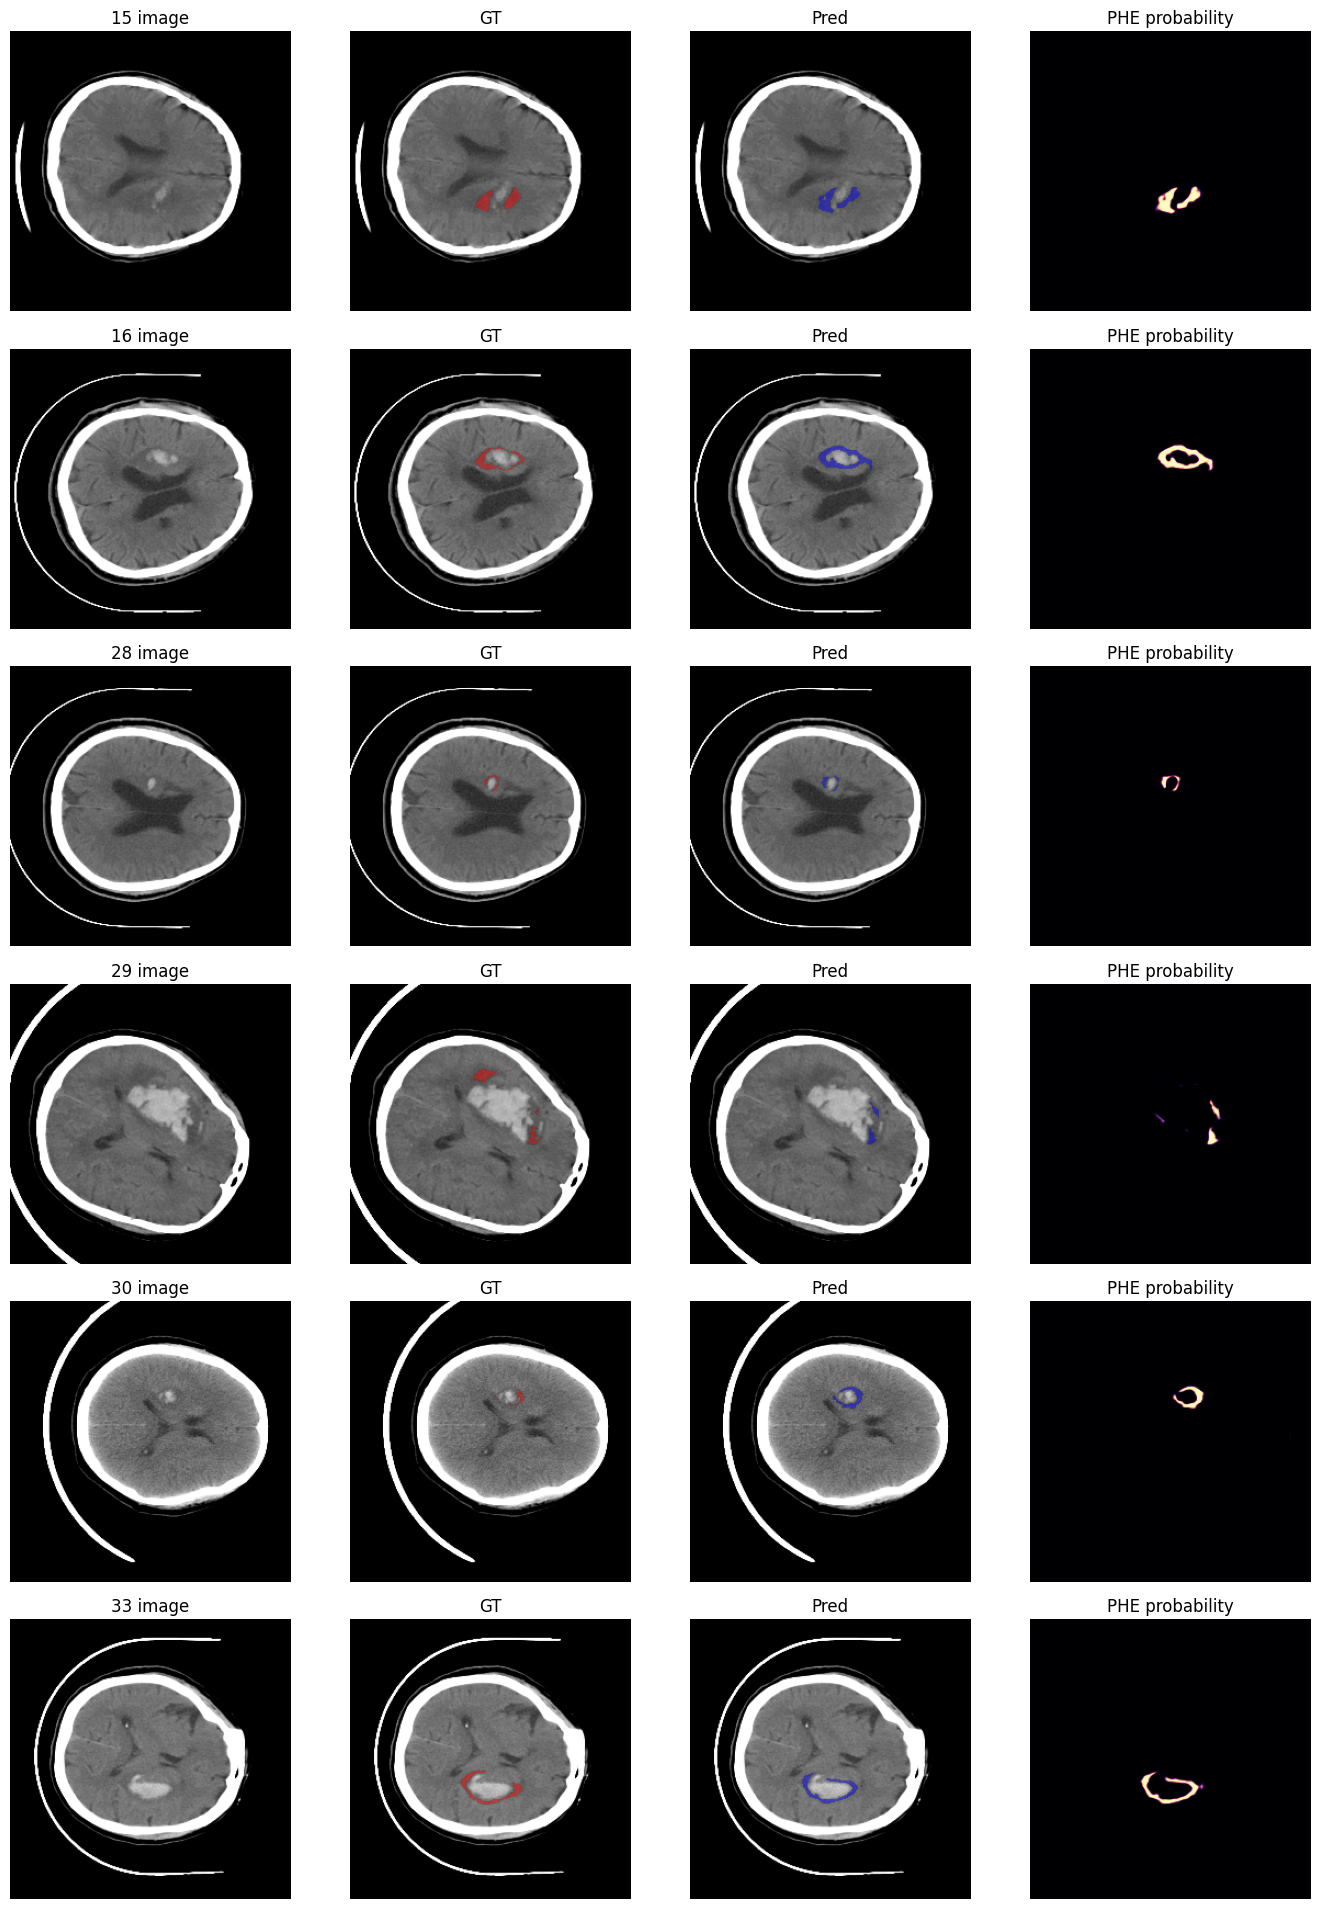

In [18]:
option1_summary_path = PROJECT_ROOT / "outputs_option1_phe_sich_2d_unet" / "tables" / "option1_legacy_slice_summary.csv"
if "legacy_summary" in globals():
    option4_summary = legacy_summary.copy()
    if option1_summary_path.exists():
        option1_summary = pd.read_csv(option1_summary_path)
        compare_summary = pd.concat([option1_summary.assign(source="option1_phe_only"), option4_summary.assign(source="option4_prior_transfer")], ignore_index=True)
        compare_summary.to_csv(TABLE_DIR / "option4_vs_option1_summary.csv", index=False)
        display(compare_summary)
    else:
        print("Option 1 summary not found:", option1_summary_path)
else:
    print("No Option 4 summary yet.")

if "qualitative_cases" in globals() and qualitative_cases:
    n = len(qualitative_cases)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n))
    if n == 1:
        axes = axes[None, :]
    for r, (scan_id, img2d, gt2d, pred2d, prob2d) in enumerate(qualitative_cases):
        axes[r, 0].imshow(img2d, cmap="gray"); axes[r, 0].set_title(f"{scan_id} image")
        axes[r, 1].imshow(img2d, cmap="gray"); axes[r, 1].imshow(np.ma.masked_where(gt2d == 0, gt2d), cmap="autumn", alpha=0.45); axes[r, 1].set_title("GT")
        axes[r, 2].imshow(img2d, cmap="gray"); axes[r, 2].imshow(np.ma.masked_where(pred2d == 0, pred2d), cmap="winter", alpha=0.45); axes[r, 2].set_title("Pred")
        axes[r, 3].imshow(prob2d, cmap="magma", vmin=0, vmax=1); axes[r, 3].set_title("PHE probability")
        for c in range(4):
            axes[r, c].axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "option4_qualitative_predictions.png", dpi=160, bbox_inches="tight")
    plt.show()


## 11. Protocol export


In [19]:
protocol = {
    "option": "Option 4 - Seg-CQ500 + INSTANCE ICH teacher prior transfer to PHE-SICH student",
    "source_datasets": ["Seg-CQ500", "INSTANCE2022"],
    "target_dataset": "PHE-SICH-CT-IDS SubdatasetA NIfTI",
    "teacher": {"task": "binary ICH segmentation", "input_window": "[-50,150] HU", "image_size": CFG.teacher_image_size},
    "student": {"task": "PHE segmentation", "input_channels": ["PHE brain window [-20,100] HU", "teacher ICH soft prior"], "image_size": CFG.student_image_size},
    "split": "Reuses Option 1 patient-level 4:4:2 split when available",
    "primary_question": "Does external ICH prior transfer improve PHE segmentation over PHE-only Option 1?",
    "metrics": {
        "legacy_phe_sich": ["Dice", "Jaccard", "full Hausdorff", "Precision", "Recall"],
        "volume_pese_instance": ["DSC", "HD", "RVD", "NSD", "volume MAE/RMSE/R2"],
    },
    "no_go": ["No RSNA/BHSD in this option", "No pseudo-IPH labels inferred from PHE edema masks"],
}
with open(LOG_DIR / "option4_protocol.json", "w", encoding="utf-8") as f:
    json.dump(protocol, f, ensure_ascii=False, indent=2, default=str)
print("Saved protocol:", LOG_DIR / "option4_protocol.json")
print("Tables :", TABLE_DIR)
print("Figures:", FIG_DIR)
print("Ckpts  :", CHECKPOINT_DIR)


Saved protocol: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\logs\option4_protocol.json
Tables : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\tables
Figures: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\figures
Ckpts  : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\checkpoints
